In [2]:
import numpy as np
import pandas as pd
import subprocess
import os
import sys
import argparse
import glob
import time
from astropy.io import fits as pyfits
import matplotlib.pyplot as plt
from urllib.request import urlopen
from astropy.table import Table
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from astropy.time import Time
from contextlib import closing
from astropy import units as u

In [14]:
# Stacked_df is before the filtering process, filtered is what we want to look at 

unfiltered_stacked_df = pd.read_pickle('unfiltered_stacked_results.pkl')
filtered_stacked_df = pd.read_pickle('filtered_stacked_results.pkl')

In [15]:
# This plots the type for whichever dataframe you're using (filtered or not filtered)

plt.rc('text', usetex=True)


def plot_stacks_for_type(
    df,
    which_type="Ia",
    *,
    type_col="type",
    array_col="stacked_array",
    time_col="time_interval",
    rms_col="rms",
    count_col="num_observations",
    peak_col="peak_L",
    cmap="inferno",
    ncols=6,
    snr_threshold=5.0,
    title=None,
    savepath=None,
    individual_scaling=True
):

    sub = df[df[type_col] == which_type]

    if sub.empty:
        raise ValueError(f"No rows found with {type_col} == {which_type}")

    num = len(sub)
    nrows = (num + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                             figsize=(4.2*ncols, 3.2*nrows))

    axes = np.atleast_1d(axes).ravel()

    cols = [array_col, time_col, rms_col, count_col, peak_col]

    for ax, row in zip(axes, sub[cols].itertuples(index=False, name=None)):

        arr, tlabel, rms, nstack, peakL = row

        if individual_scaling:
            vmin, vmax = np.nanmin(arr), np.nanmax(arr)

        snr = peakL / rms if rms != 0 else np.nan

        ax.imshow(arr, cmap=cmap, interpolation="nearest", vmin=vmin, vmax=vmax)

        ax.set_title(f"{tlabel}", fontsize=11)

        ax.set_xlabel(
            rf"RMS: {rms:.3e}, Stacked: {int(nstack)}" "\n"
            rf"Max $L$: {peakL:.3e}, S/N: {snr:.2f}",
            fontsize=9
        )

        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

        edge = "lime" if (np.isfinite(snr) and snr >= snr_threshold) else "black"
        lw = 4 if edge == "lime" else 1

        for spine in ax.spines.values():
            spine.set_edgecolor(edge)
            spine.set_linewidth(lw)

    for ax in axes[num:]:
        ax.axis("off")

    fig.suptitle(title, fontsize=18, x=0.5, y=0.98)

    plt.subplots_adjust(top=0.90, hspace=0.4)

    if savepath:
        plt.savefig(savepath, format="pdf", bbox_inches="tight")

    plt.show()

    return fig, axes

In [16]:
### Use this if you want to compare 


def plot_stacks_for_type_combined(
    df_all,
    df_filt,
    which_type="Ia",
    *,
    type_col="type",
    array_col="stacked_array",
    time_col="time_interval",
    rms_col="rms",
    count_col="num_observations",
    peak_col="peak_L",
    cmap="inferno",
    ncols=6,
    snr_threshold=5.0,
    title=None,
    savepath=None,
    individual_scaling=True,
    row_titles=("All", "Filtered")
):

    sub_all  = df_all[df_all[type_col] == which_type]
    sub_filt = df_filt[df_filt[type_col] == which_type]

    if sub_all.empty and sub_filt.empty:
        raise ValueError(f"No rows found with {type_col} == {which_type} in either dataframe")

    # Determine how many panels per row (can differ)
    num_all  = len(sub_all)
    num_filt = len(sub_filt)

    nrows_all  = (num_all  + ncols - 1) // ncols if num_all  > 0 else 1
    nrows_filt = (num_filt + ncols - 1) // ncols if num_filt > 0 else 1

    # Total rows in the matplotlib grid
    nrows = nrows_all + nrows_filt

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(4.2*ncols, 3.2*nrows)
    )
    axes = np.atleast_2d(axes)  # shape (nrows, ncols)

    cols = [array_col, time_col, rms_col, count_col, peak_col]

    def _plot_into_rowblock(sub, axes_block, block_label):
        """Plot a 'sub' dataframe into a contiguous block of rows in axes."""
        if sub.empty:
            # turn off all axes in this block if empty
            for ax in axes_block.ravel():
                ax.axis("off")
            return

        # optional: enforce consistent ordering by time label if needed
        # sub = sub.sort_values(time_col)

        flat_axes = axes_block.ravel()

        for ax, row in zip(flat_axes, sub[cols].itertuples(index=False, name=None)):
            arr, tlabel, rms, nstack, peakL = row

            if individual_scaling:
                vmin, vmax = np.nanmin(arr), np.nanmax(arr)
            else:
                vmin, vmax = None, None  # matplotlib defaults

            snr = peakL / rms if rms != 0 else np.nan

            ax.imshow(arr, cmap=cmap, interpolation="nearest", vmin=vmin, vmax=vmax)
            ax.set_title(f"{tlabel}", fontsize=11)

            ax.set_xlabel(
                rf"RMS: {rms:.3e}, Stacked: {int(nstack)}" "\n"
                rf"Max $L$: {peakL:.3e}, S/N: {snr:.2f}",
                fontsize=9
            )

            ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

            edge = "lime" if (np.isfinite(snr) and snr >= snr_threshold) else "black"
            lw = 4 if edge == "lime" else 1
            for spine in ax.spines.values():
                spine.set_edgecolor(edge)
                spine.set_linewidth(lw)

        # turn off unused panels in this block
        used = len(sub)
        for ax in flat_axes[used:]:
            ax.axis("off")

        # Put a row label on the left of the first axis in the block
        # (doesn't affect your panel style)
        axes_block[0, 0].set_ylabel(block_label, fontsize=14, rotation=90, labelpad=20)

    # Split the axes grid into two blocks: top for all, bottom for filtered
    axes_all  = axes[:nrows_all, :]
    axes_filt = axes[nrows_all:, :]

    _plot_into_rowblock(sub_all,  axes_all,  row_titles[0])
    _plot_into_rowblock(sub_filt, axes_filt, row_titles[1])

    if title is None:
        title = rf"{which_type} stacks: {row_titles[0]} vs {row_titles[1]}"

    fig.suptitle(title, fontsize=18, x=0.5, y=0.985)
    plt.subplots_adjust(top=0.93, hspace=0.55)

    if savepath:
        plt.savefig(savepath, format="pdf", bbox_inches="tight")

    plt.show()
    return fig, axes

In [ ]:
# Example of using the above function:

# plot_stacks_for_type_combined(stacked_df, filtered_stacked_df, 'Ia')

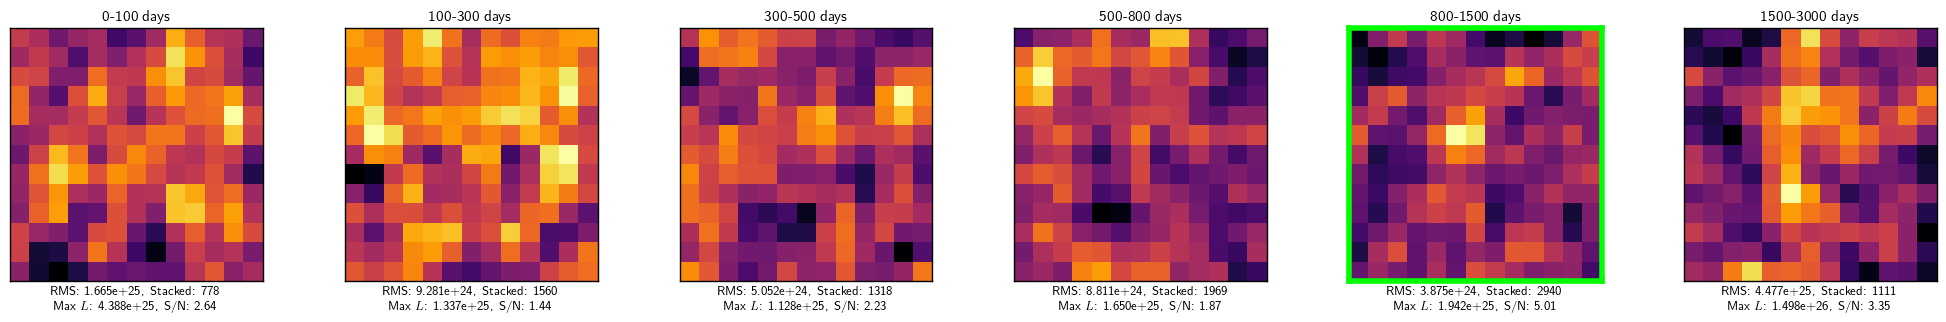

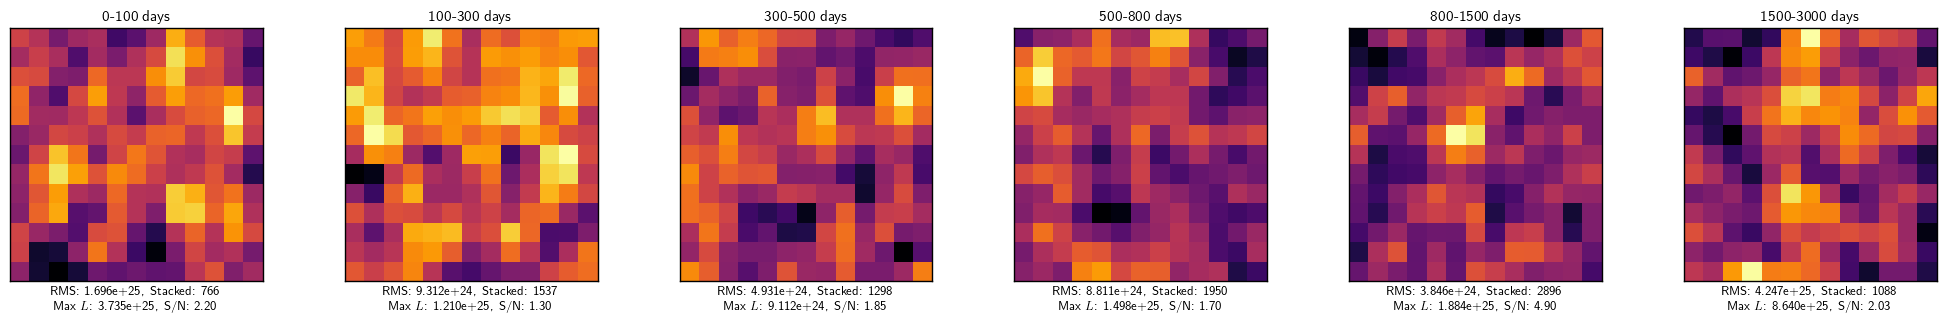

(<Figure size 2520x320 with 6 Axes>,
 array([<Axes: title={'center': '0-100 days'}, xlabel='RMS: 1.696e+25, Stacked: 766\nMax $L$: 3.735e+25, S/N: 2.20'>,
        <Axes: title={'center': '100-300 days'}, xlabel='RMS: 9.312e+24, Stacked: 1537\nMax $L$: 1.210e+25, S/N: 1.30'>,
        <Axes: title={'center': '300-500 days'}, xlabel='RMS: 4.931e+24, Stacked: 1298\nMax $L$: 9.112e+24, S/N: 1.85'>,
        <Axes: title={'center': '500-800 days'}, xlabel='RMS: 8.811e+24, Stacked: 1950\nMax $L$: 1.498e+25, S/N: 1.70'>,
        <Axes: title={'center': '800-1500 days'}, xlabel='RMS: 3.846e+24, Stacked: 2896\nMax $L$: 1.884e+25, S/N: 4.90'>,
        <Axes: title={'center': '1500-3000 days'}, xlabel='RMS: 4.247e+25, Stacked: 1088\nMax $L$: 8.640e+25, S/N: 2.03'>],
       dtype=object))

In [17]:
plot_stacks_for_type(unfiltered_stacked_df, which_type = "Ia",
                     ncols = 6)
plot_stacks_for_type(filtered_stacked_df, which_type = "Ia",
                     ncols = 6)

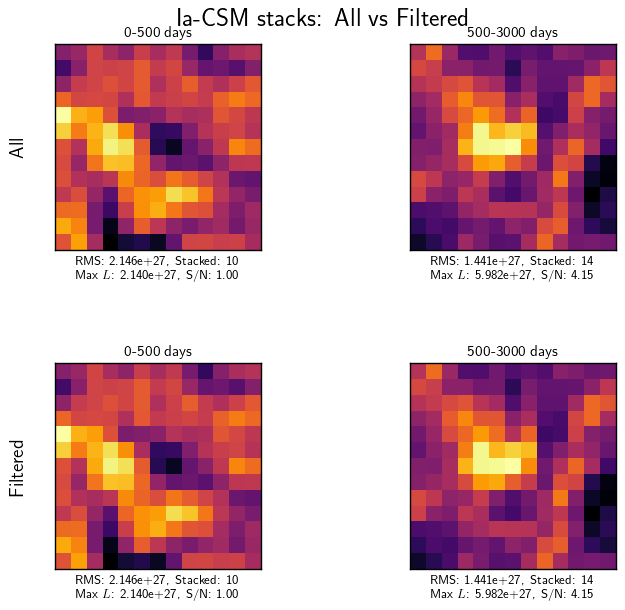

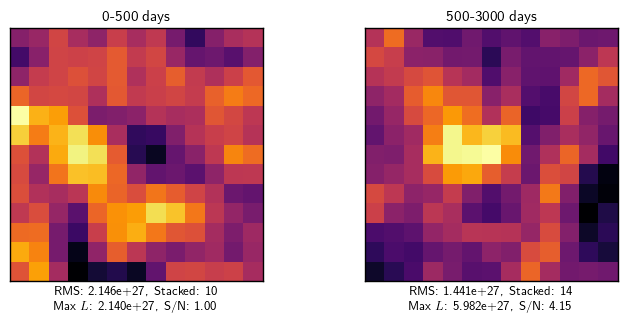

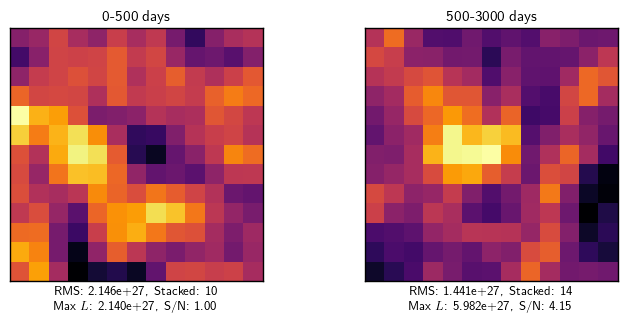

(<Figure size 840x320 with 2 Axes>,
 array([<Axes: title={'center': '0-500 days'}, xlabel='RMS: 2.146e+27, Stacked: 10\nMax $L$: 2.140e+27, S/N: 1.00'>,
        <Axes: title={'center': '500-3000 days'}, xlabel='RMS: 1.441e+27, Stacked: 14\nMax $L$: 5.982e+27, S/N: 4.15'>],
       dtype=object))

In [19]:
plot_stacks_for_type_combined(unfiltered_stacked_df, filtered_stacked_df, 'Ia-CSM', ncols = 2)
plot_stacks_for_type(unfiltered_stacked_df, which_type = "Ia-CSM",
                     ncols = 2)
plot_stacks_for_type(filtered_stacked_df, which_type = "Ia-CSM",
                     ncols = 2)

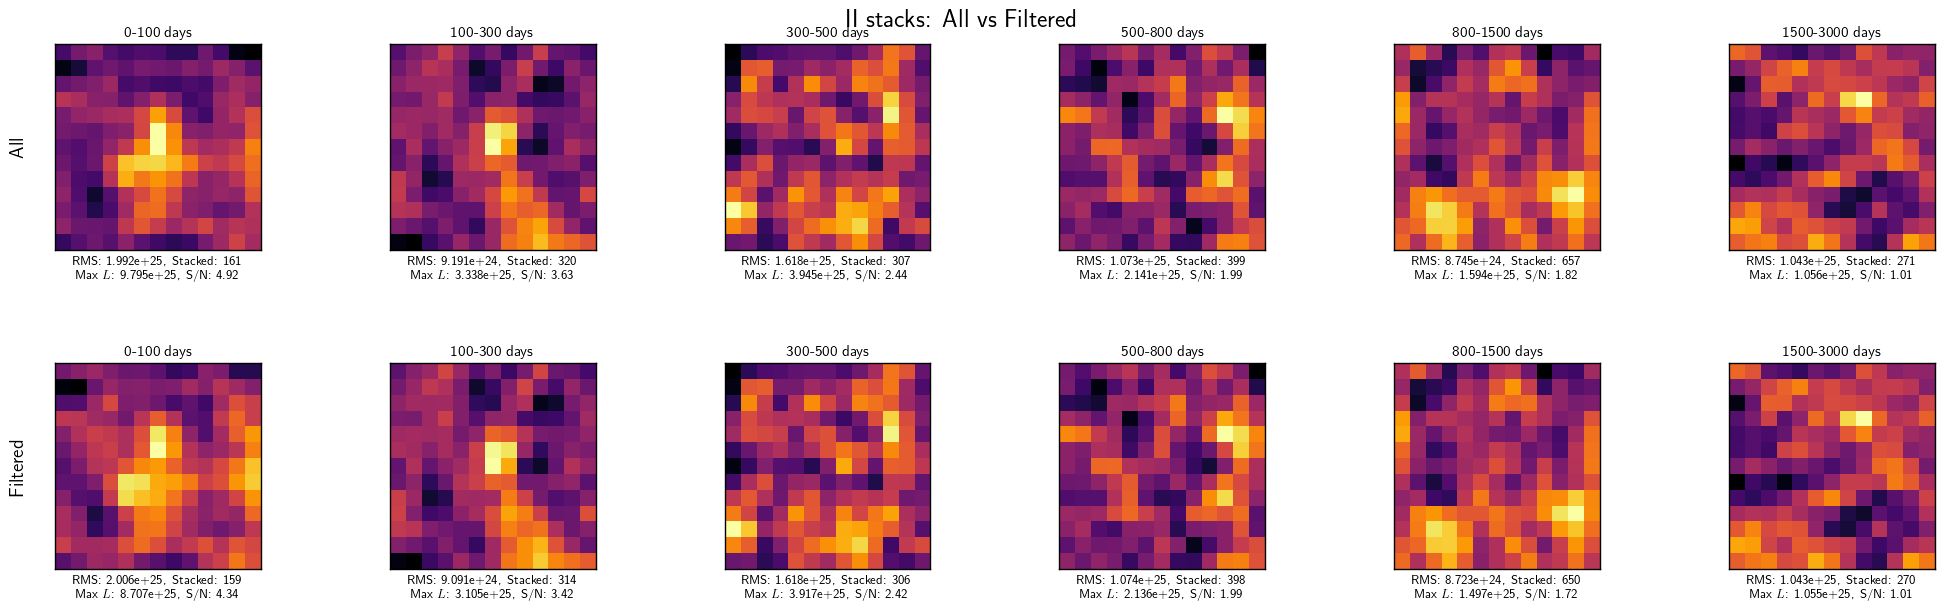

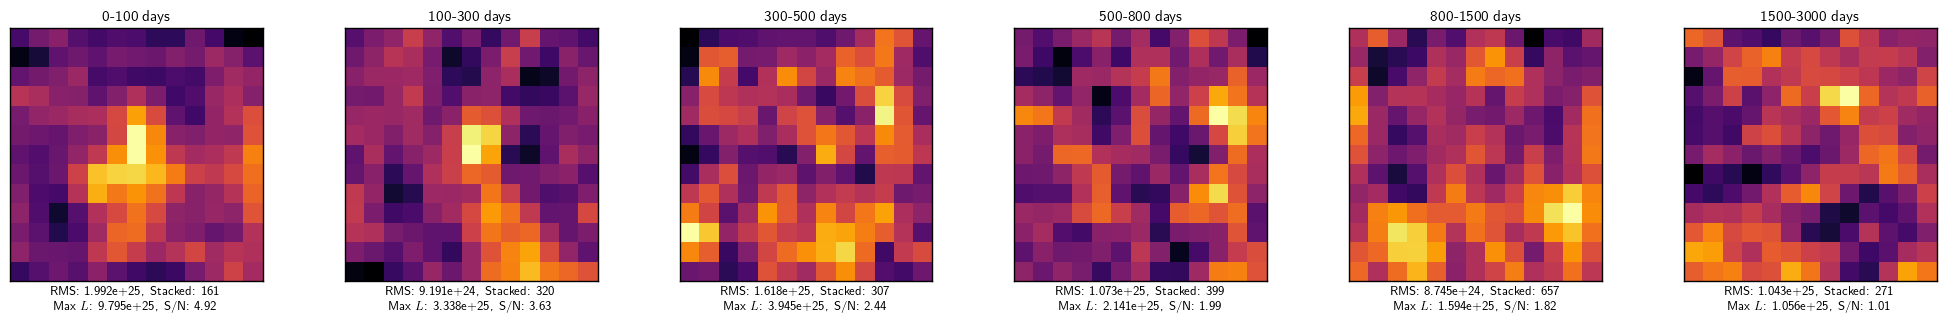

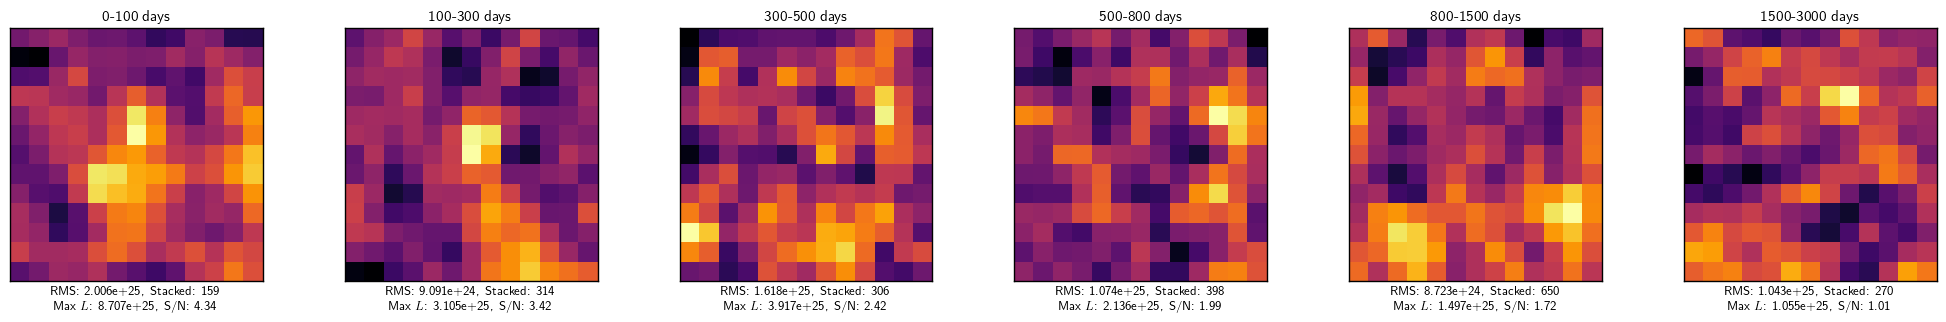

(<Figure size 2520x320 with 6 Axes>,
 array([<Axes: title={'center': '0-100 days'}, xlabel='RMS: 2.006e+25, Stacked: 159\nMax $L$: 8.707e+25, S/N: 4.34'>,
        <Axes: title={'center': '100-300 days'}, xlabel='RMS: 9.091e+24, Stacked: 314\nMax $L$: 3.105e+25, S/N: 3.42'>,
        <Axes: title={'center': '300-500 days'}, xlabel='RMS: 1.618e+25, Stacked: 306\nMax $L$: 3.917e+25, S/N: 2.42'>,
        <Axes: title={'center': '500-800 days'}, xlabel='RMS: 1.074e+25, Stacked: 398\nMax $L$: 2.136e+25, S/N: 1.99'>,
        <Axes: title={'center': '800-1500 days'}, xlabel='RMS: 8.723e+24, Stacked: 650\nMax $L$: 1.497e+25, S/N: 1.72'>,
        <Axes: title={'center': '1500-3000 days'}, xlabel='RMS: 1.043e+25, Stacked: 270\nMax $L$: 1.055e+25, S/N: 1.01'>],
       dtype=object))

In [18]:
plot_stacks_for_type_combined(unfiltered_stacked_df, filtered_stacked_df, 'II')
plot_stacks_for_type(unfiltered_stacked_df, which_type = "II",
                     ncols = 6)
plot_stacks_for_type(filtered_stacked_df, which_type = "II",
                     ncols = 6)

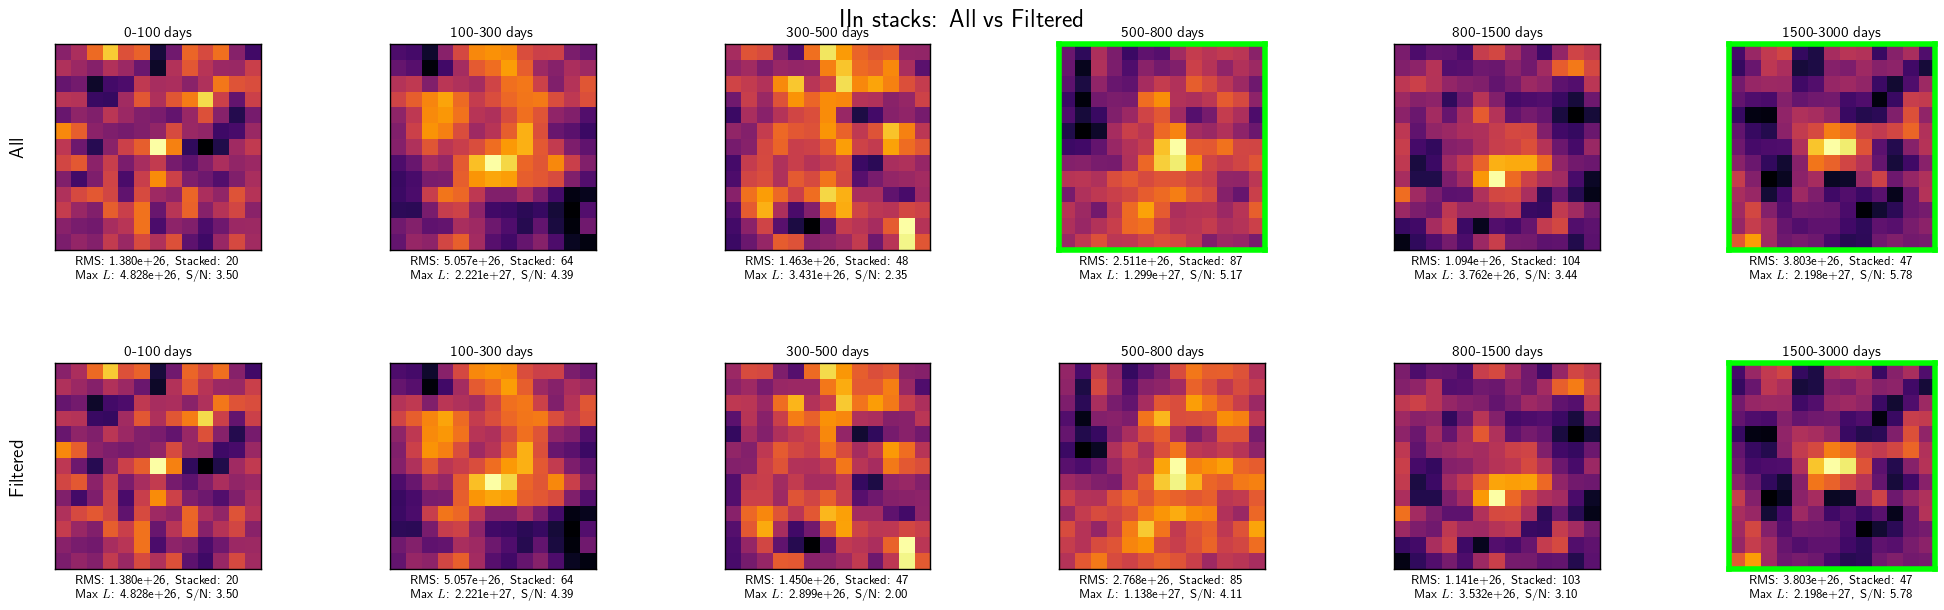

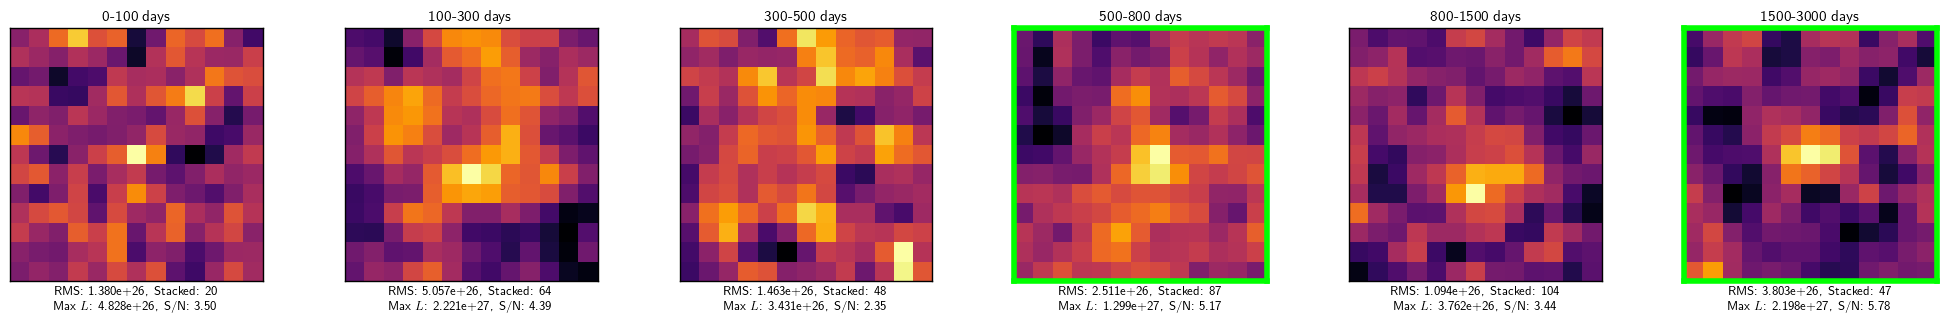

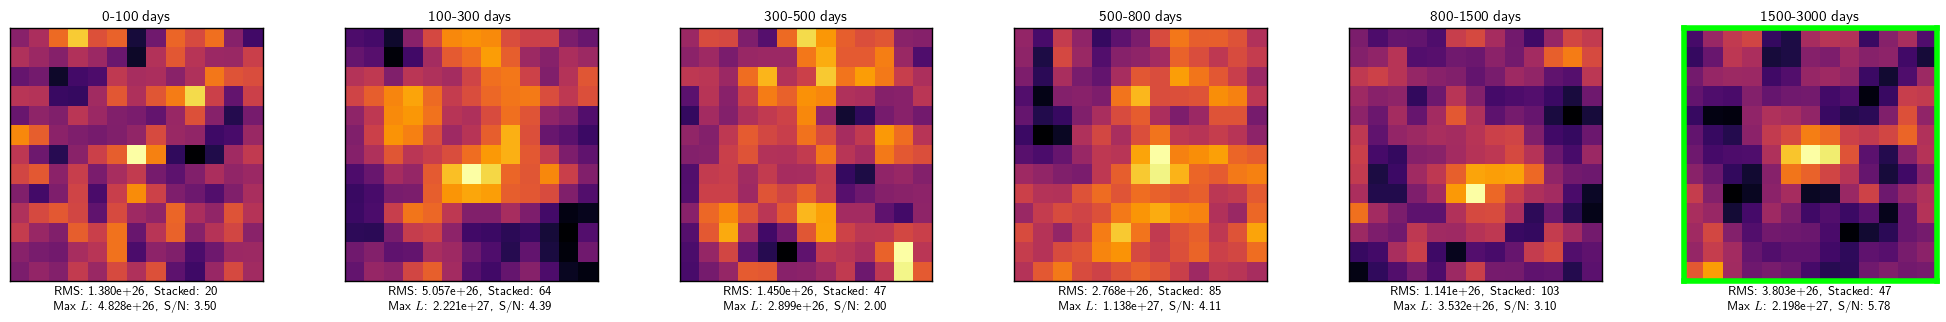

(<Figure size 2520x320 with 6 Axes>,
 array([<Axes: title={'center': '0-100 days'}, xlabel='RMS: 1.380e+26, Stacked: 20\nMax $L$: 4.828e+26, S/N: 3.50'>,
        <Axes: title={'center': '100-300 days'}, xlabel='RMS: 5.057e+26, Stacked: 64\nMax $L$: 2.221e+27, S/N: 4.39'>,
        <Axes: title={'center': '300-500 days'}, xlabel='RMS: 1.450e+26, Stacked: 47\nMax $L$: 2.899e+26, S/N: 2.00'>,
        <Axes: title={'center': '500-800 days'}, xlabel='RMS: 2.768e+26, Stacked: 85\nMax $L$: 1.138e+27, S/N: 4.11'>,
        <Axes: title={'center': '800-1500 days'}, xlabel='RMS: 1.141e+26, Stacked: 103\nMax $L$: 3.532e+26, S/N: 3.10'>,
        <Axes: title={'center': '1500-3000 days'}, xlabel='RMS: 3.803e+26, Stacked: 47\nMax $L$: 2.198e+27, S/N: 5.78'>],
       dtype=object))

In [20]:
plot_stacks_for_type_combined(unfiltered_stacked_df, filtered_stacked_df, 'IIn')

plot_stacks_for_type(unfiltered_stacked_df, which_type = "IIn",
                     ncols = 6)
plot_stacks_for_type(filtered_stacked_df, which_type = "IIn",
                     ncols = 6)

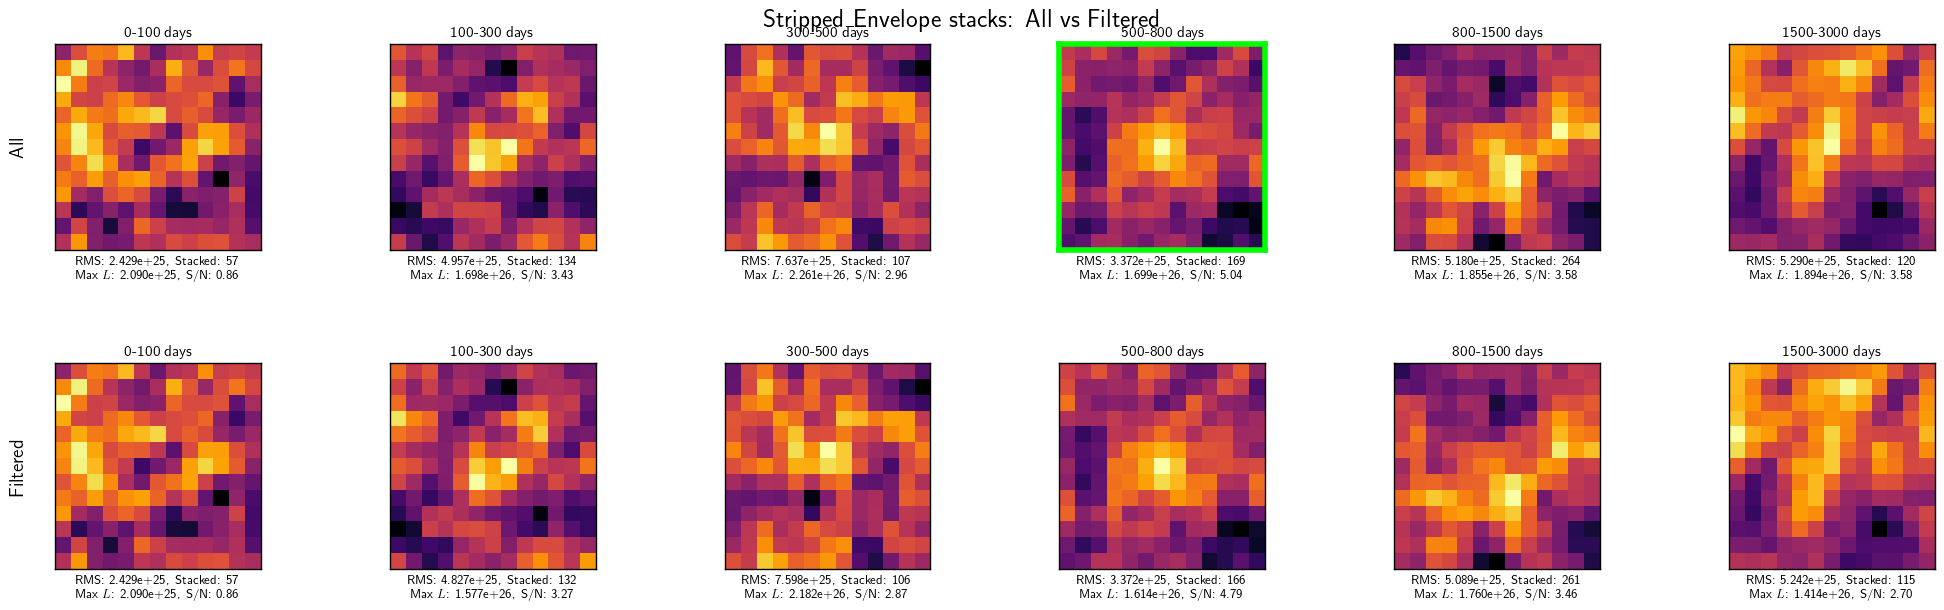

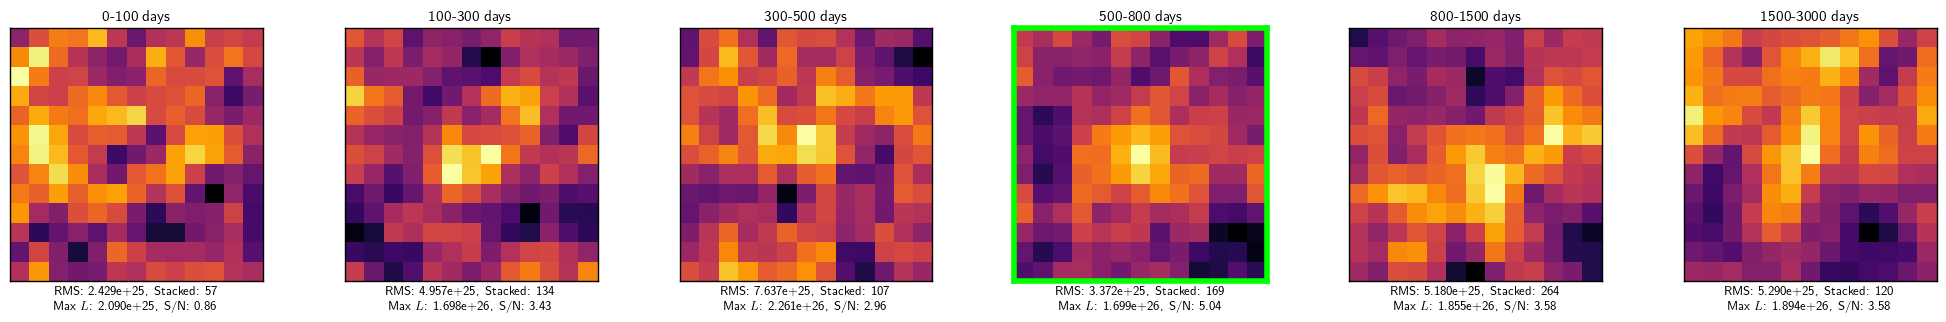

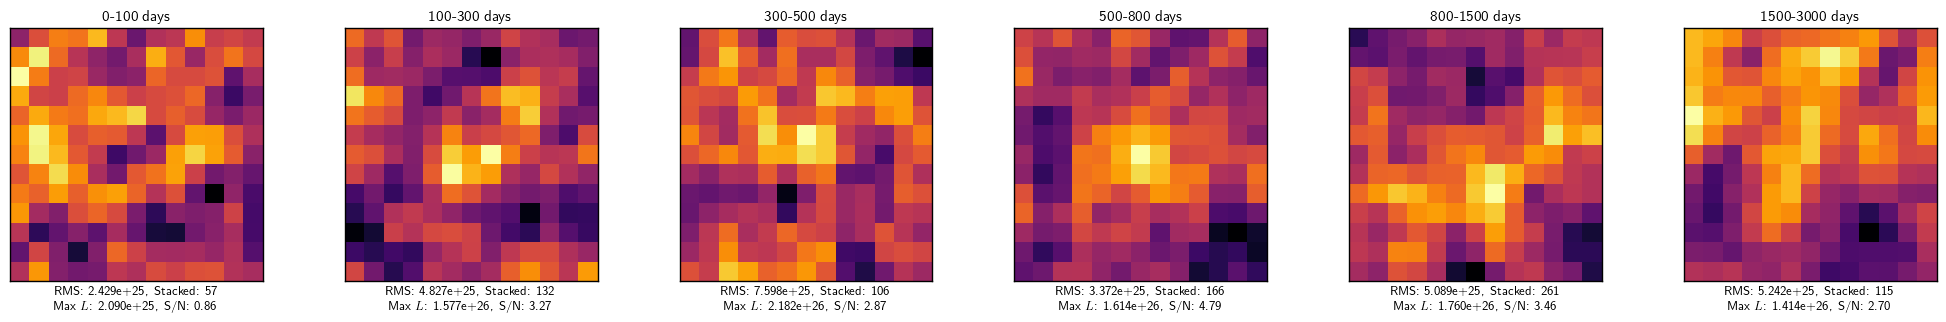

(<Figure size 2520x320 with 6 Axes>,
 array([<Axes: title={'center': '0-100 days'}, xlabel='RMS: 2.429e+25, Stacked: 57\nMax $L$: 2.090e+25, S/N: 0.86'>,
        <Axes: title={'center': '100-300 days'}, xlabel='RMS: 4.827e+25, Stacked: 132\nMax $L$: 1.577e+26, S/N: 3.27'>,
        <Axes: title={'center': '300-500 days'}, xlabel='RMS: 7.598e+25, Stacked: 106\nMax $L$: 2.182e+26, S/N: 2.87'>,
        <Axes: title={'center': '500-800 days'}, xlabel='RMS: 3.372e+25, Stacked: 166\nMax $L$: 1.614e+26, S/N: 4.79'>,
        <Axes: title={'center': '800-1500 days'}, xlabel='RMS: 5.089e+25, Stacked: 261\nMax $L$: 1.760e+26, S/N: 3.46'>,
        <Axes: title={'center': '1500-3000 days'}, xlabel='RMS: 5.242e+25, Stacked: 115\nMax $L$: 1.414e+26, S/N: 2.70'>],
       dtype=object))

In [21]:
plot_stacks_for_type_combined(unfiltered_stacked_df, filtered_stacked_df, 'Stripped_Envelope')

plot_stacks_for_type(unfiltered_stacked_df, which_type = "Stripped_Envelope",
                     ncols = 6)
plot_stacks_for_type(filtered_stacked_df, which_type = "Stripped_Envelope",
                     ncols = 6)

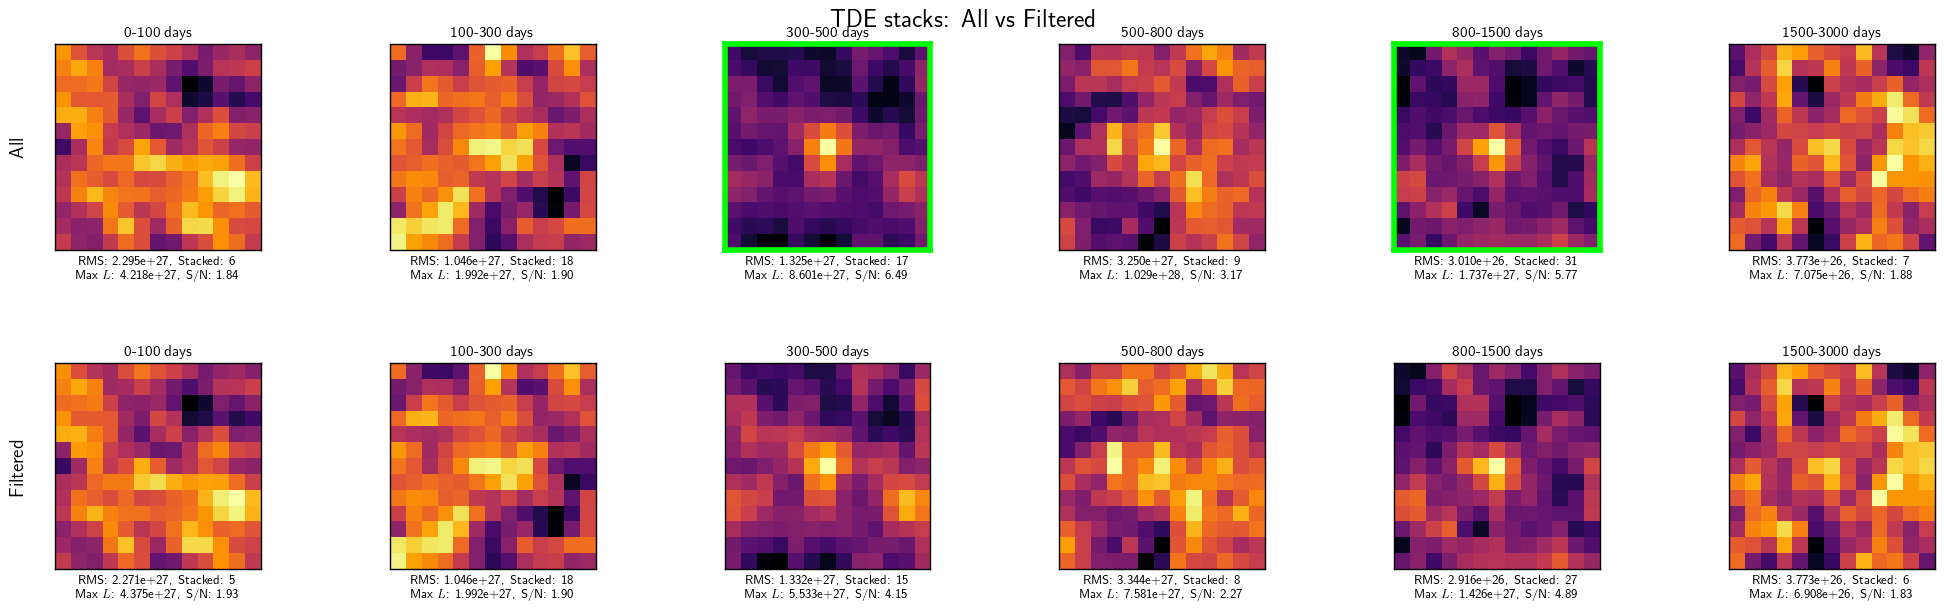

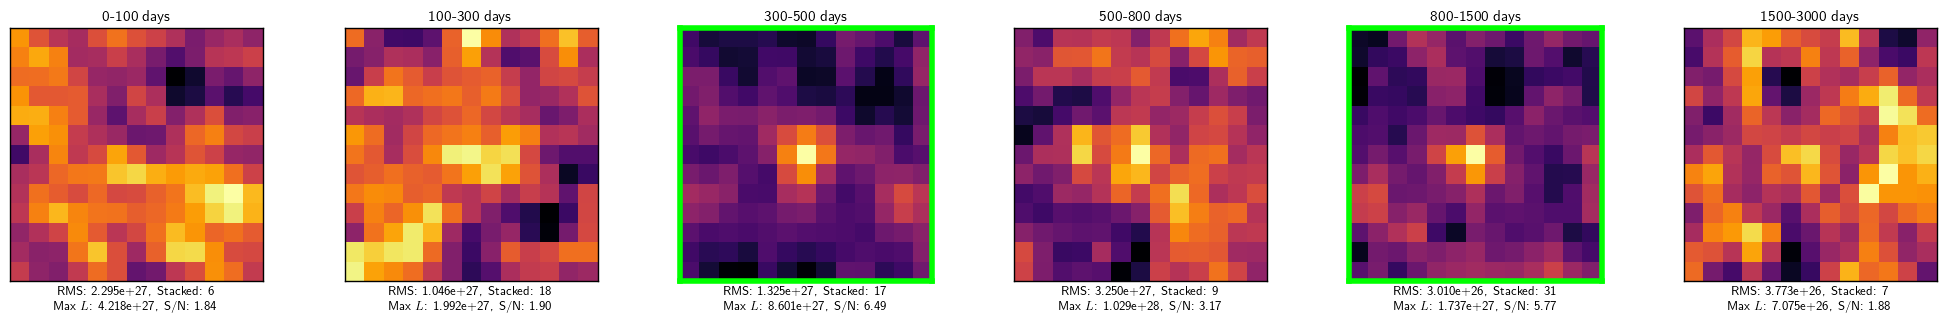

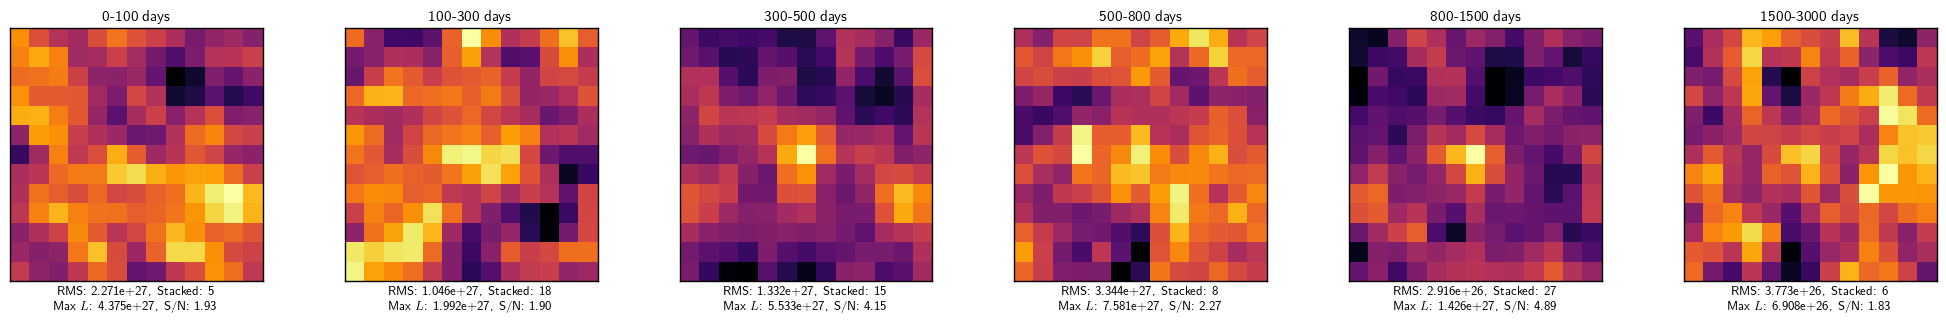

(<Figure size 2520x320 with 6 Axes>,
 array([<Axes: title={'center': '0-100 days'}, xlabel='RMS: 2.271e+27, Stacked: 5\nMax $L$: 4.375e+27, S/N: 1.93'>,
        <Axes: title={'center': '100-300 days'}, xlabel='RMS: 1.046e+27, Stacked: 18\nMax $L$: 1.992e+27, S/N: 1.90'>,
        <Axes: title={'center': '300-500 days'}, xlabel='RMS: 1.332e+27, Stacked: 15\nMax $L$: 5.533e+27, S/N: 4.15'>,
        <Axes: title={'center': '500-800 days'}, xlabel='RMS: 3.344e+27, Stacked: 8\nMax $L$: 7.581e+27, S/N: 2.27'>,
        <Axes: title={'center': '800-1500 days'}, xlabel='RMS: 2.916e+26, Stacked: 27\nMax $L$: 1.426e+27, S/N: 4.89'>,
        <Axes: title={'center': '1500-3000 days'}, xlabel='RMS: 3.773e+26, Stacked: 6\nMax $L$: 6.908e+26, S/N: 1.83'>],
       dtype=object))

In [22]:
plot_stacks_for_type_combined(unfiltered_stacked_df, filtered_stacked_df, 'TDE')

plot_stacks_for_type(unfiltered_stacked_df, which_type = "TDE",
                     ncols = 6)
plot_stacks_for_type(filtered_stacked_df, which_type = "TDE",
                     ncols = 6)

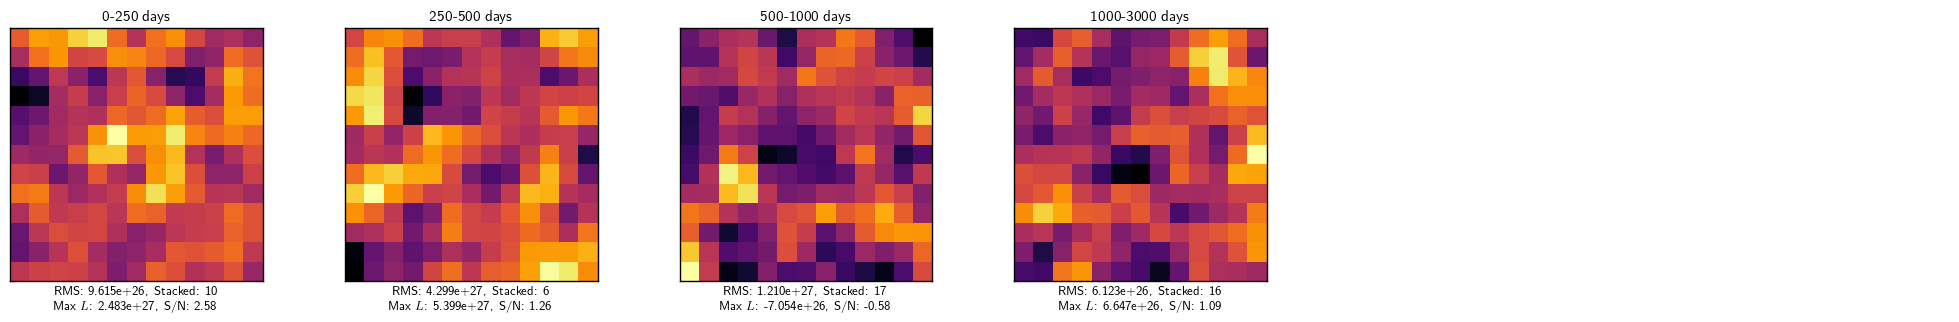

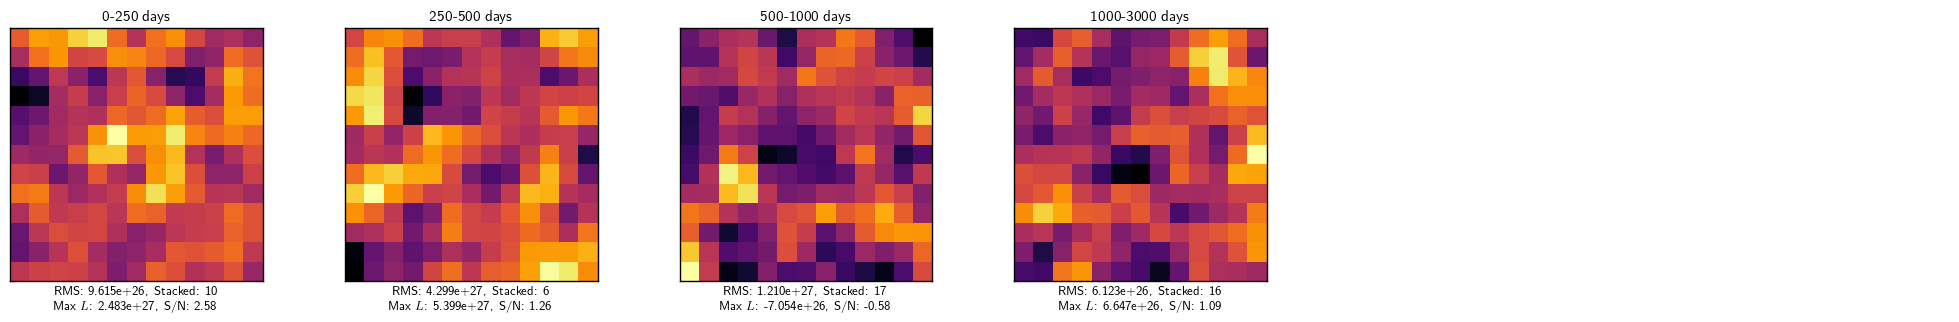

(<Figure size 2520x320 with 6 Axes>,
 array([<Axes: title={'center': '0-250 days'}, xlabel='RMS: 9.615e+26, Stacked: 10\nMax $L$: 2.483e+27, S/N: 2.58'>,
        <Axes: title={'center': '250-500 days'}, xlabel='RMS: 4.299e+27, Stacked: 6\nMax $L$: 5.399e+27, S/N: 1.26'>,
        <Axes: title={'center': '500-1000 days'}, xlabel='RMS: 1.210e+27, Stacked: 17\nMax $L$: -7.054e+26, S/N: -0.58'>,
        <Axes: title={'center': '1000-3000 days'}, xlabel='RMS: 6.123e+26, Stacked: 16\nMax $L$: 6.647e+26, S/N: 1.09'>,
        <Axes: >, <Axes: >], dtype=object))

In [23]:
plot_stacks_for_type(unfiltered_stacked_df, which_type = "Ibn/Icn",
                     ncols = 6)
plot_stacks_for_type(filtered_stacked_df, which_type = "Ibn/Icn",
                     ncols = 6)

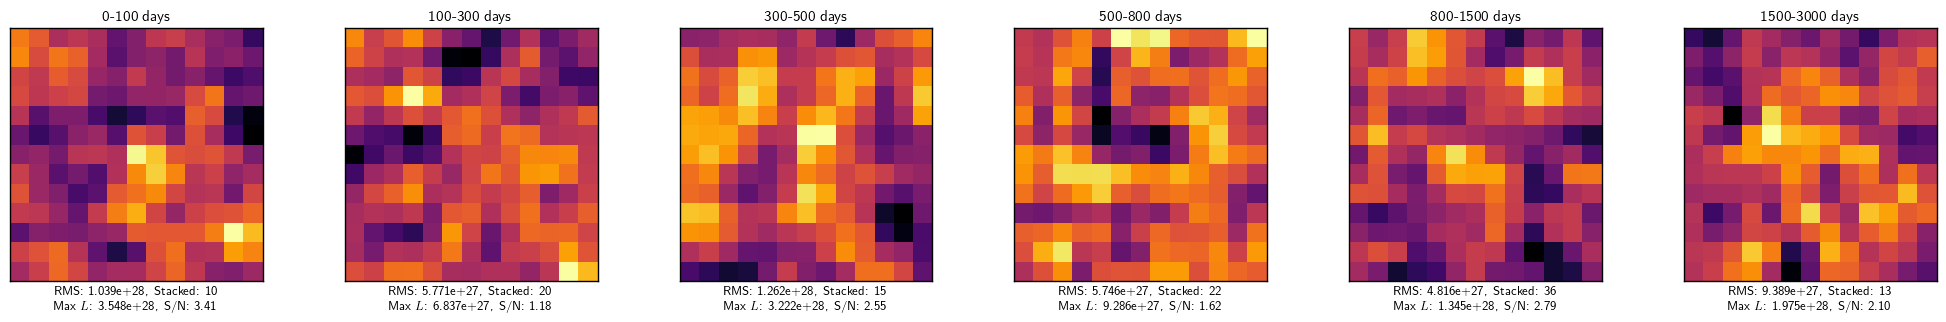

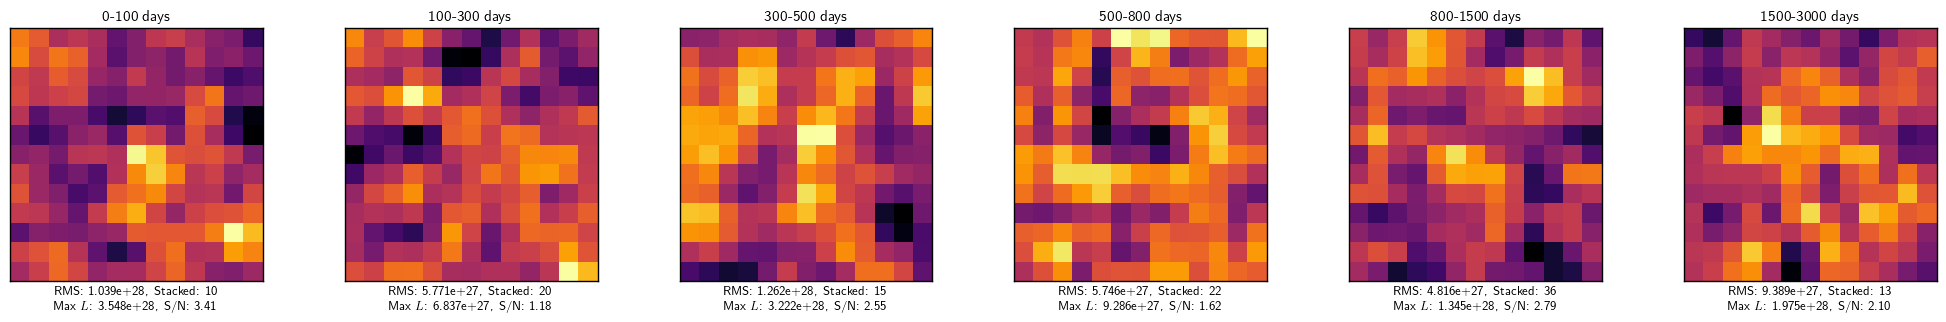

(<Figure size 2520x320 with 6 Axes>,
 array([<Axes: title={'center': '0-100 days'}, xlabel='RMS: 1.039e+28, Stacked: 10\nMax $L$: 3.548e+28, S/N: 3.41'>,
        <Axes: title={'center': '100-300 days'}, xlabel='RMS: 5.771e+27, Stacked: 20\nMax $L$: 6.837e+27, S/N: 1.18'>,
        <Axes: title={'center': '300-500 days'}, xlabel='RMS: 1.262e+28, Stacked: 15\nMax $L$: 3.222e+28, S/N: 2.55'>,
        <Axes: title={'center': '500-800 days'}, xlabel='RMS: 5.746e+27, Stacked: 22\nMax $L$: 9.286e+27, S/N: 1.62'>,
        <Axes: title={'center': '800-1500 days'}, xlabel='RMS: 4.816e+27, Stacked: 36\nMax $L$: 1.345e+28, S/N: 2.79'>,
        <Axes: title={'center': '1500-3000 days'}, xlabel='RMS: 9.389e+27, Stacked: 13\nMax $L$: 1.975e+28, S/N: 2.10'>],
       dtype=object))

In [24]:
plot_stacks_for_type(unfiltered_stacked_df, which_type = "SLSN-I",
                     ncols = 6)
plot_stacks_for_type(filtered_stacked_df, which_type = "SLSN-I",
                     ncols = 6)

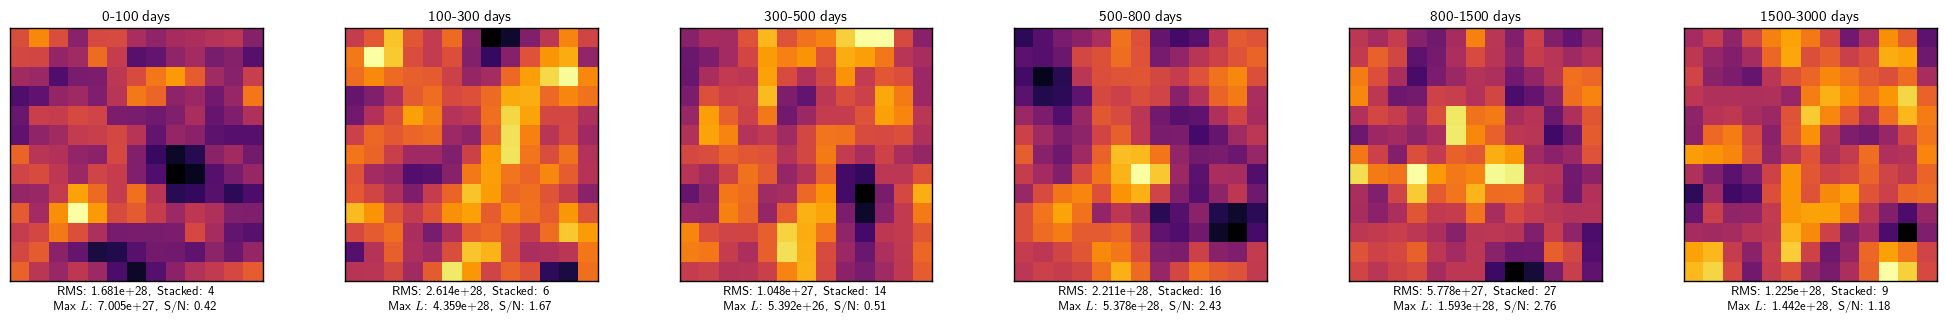

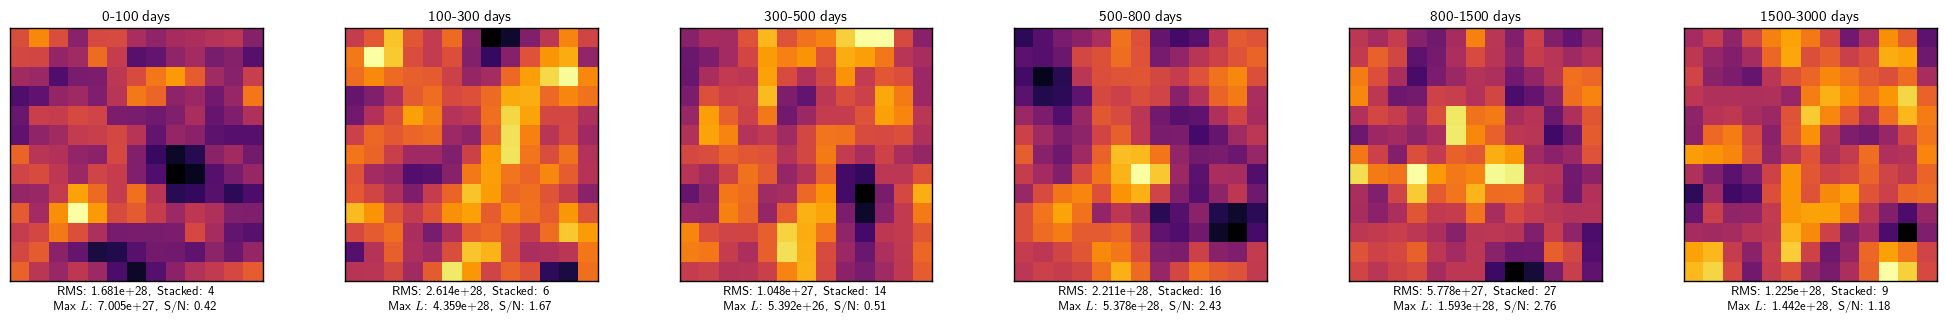

(<Figure size 2520x320 with 6 Axes>,
 array([<Axes: title={'center': '0-100 days'}, xlabel='RMS: 1.681e+28, Stacked: 4\nMax $L$: 7.005e+27, S/N: 0.42'>,
        <Axes: title={'center': '100-300 days'}, xlabel='RMS: 2.614e+28, Stacked: 6\nMax $L$: 4.359e+28, S/N: 1.67'>,
        <Axes: title={'center': '300-500 days'}, xlabel='RMS: 1.048e+27, Stacked: 14\nMax $L$: 5.392e+26, S/N: 0.51'>,
        <Axes: title={'center': '500-800 days'}, xlabel='RMS: 2.211e+28, Stacked: 16\nMax $L$: 5.378e+28, S/N: 2.43'>,
        <Axes: title={'center': '800-1500 days'}, xlabel='RMS: 5.778e+27, Stacked: 27\nMax $L$: 1.593e+28, S/N: 2.76'>,
        <Axes: title={'center': '1500-3000 days'}, xlabel='RMS: 1.225e+28, Stacked: 9\nMax $L$: 1.442e+28, S/N: 1.18'>],
       dtype=object))

In [25]:
plot_stacks_for_type(unfiltered_stacked_df, which_type = "SLSN-II",
                     ncols = 6)
plot_stacks_for_type(filtered_stacked_df, which_type = "SLSN-II",
                     ncols = 6)